## Análisis exploratorio, reducción de dimensionalidad y segmentación de clientes

### Descripción:

En este ejercicio integrador se aplican técnicas de análisis exploratorio de datos, reducción de dimensionalidad mediante PCA y agrupamiento con clustering. Se busca analizar un conjunto de datos de clientes para identificar patrones y segmentarlos en grupos según las variables Edad, Ingresos y Experiencia.

In [21]:
# Crear DataFrame con datos de clientes
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Crear DataFrame
df = pd.DataFrame({
    "Cliente": [1, 2, 3, 4, 5, 6, 7, 8],
    "Edad": [25, 40, 35, 50, 30, 45, 38, 29],
    "Ingresos": [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    "Experiencia": [2, 10, 7, 15, 3, 20, 12, 4]
})

df

,Cliente,Edad,Ingresos,Experiencia
0,1,25,50000,2
1,2,40,60000,10
2,3,35,70000,7
3,4,50,80000,15
4,5,30,45000,3
5,6,45,85000,20
6,7,38,72000,12
7,8,29,48000,4


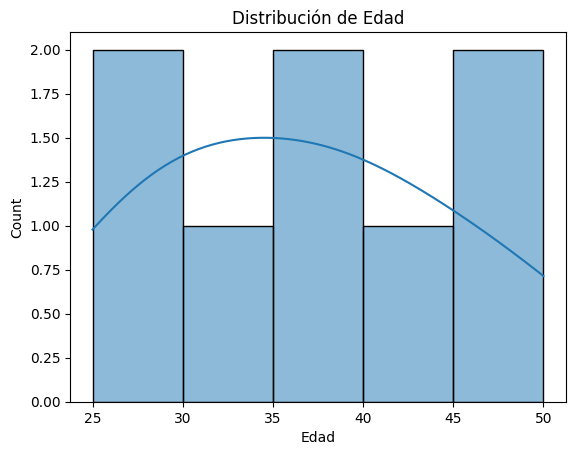

In [22]:
# Histograma de la variable Edad

sns.histplot(df["Edad"], bins=5, kde=True)

plt.title("Distribución de Edad")

plt.show()

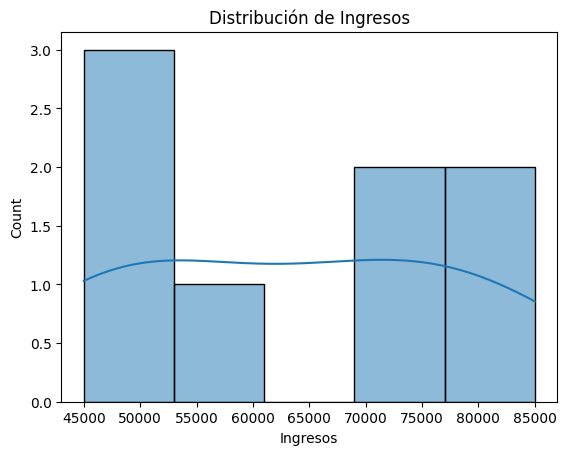

In [23]:
# Histograma de la variable Ingresos

sns.histplot(df["Ingresos"], bins=5, kde=True)

plt.title("Distribución de Ingresos")

plt.show()

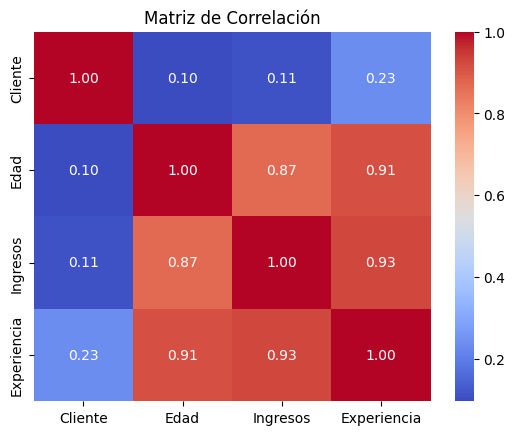

In [24]:
# Matriz de correlación entre variables numéricas
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matriz de Correlación")

plt.show()


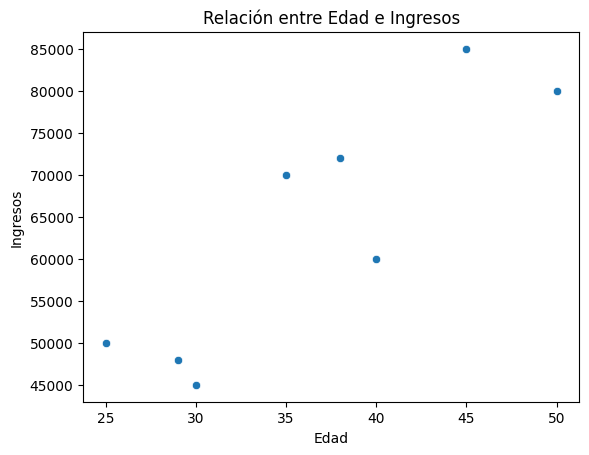

In [25]:
# Relación entre Edad e Ingresos
sns.scatterplot(x=df["Edad"], y=df["Ingresos"])

plt.title("Relación entre Edad e Ingresos")
plt.xlabel("Edad")
plt.ylabel("Ingresos")

plt.show()

In [26]:
# Normalizar las variables numéricas

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df[["Edad", "Ingresos", "Experiencia"]])

df_scaled

array([[-1.45174713, -0.96461543, -1.20246742],
       [ 0.44183608, -0.26307694,  0.14767144],
       [-0.18935832,  0.43846156, -0.35863063],
       [ 1.70422489,  1.14000005,  0.99150823],
       [-0.82055272, -1.31538468, -1.03370007],
       [ 1.07303049,  1.4907693 ,  1.83534501],
       [ 0.18935832,  0.57876926,  0.48520615],
       [-0.9467916 , -1.10492313, -0.86493271]])

In [27]:
# Varianza explicada acumulada (PCA)

pca_full = PCA()
pca_full.fit(df_scaled)

varianza_acumulada = pca_full.explained_variance_ratio_.cumsum()

print(varianza_acumulada)

print("Con 2 componentes se explica más del 90% de la varianza.")

[0.9362353  0.97922665 1.        ]
Con 2 componentes se explica más del 90% de la varianza.


In [28]:
# Aplicar PCA
pca = PCA(n_components=2)

df_pca = pca.fit_transform(df_scaled)

df_pca

array([[-2.08835804, -0.34925752],
       [ 0.18760694,  0.48746864],
       [-0.06537405, -0.38421696],
       [ 2.21059093,  0.4525092 ],
       [-1.83056536,  0.33583852],
       [ 2.54420961, -0.34683254],
       [ 0.72495206, -0.28161095],
       [-1.68306209,  0.0861016 ]])

In [29]:
# Convertir a DataFrame con componentes principales
df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])

df_pca

,PC1,PC2
0,-2.088358,-0.349258
1,0.187607,0.487469
2,-0.065374,-0.384217
3,2.210591,0.452509
4,-1.830565,0.335839
5,2.544210,-0.346833
6,0.724952,-0.281611
7,-1.683062,0.086102


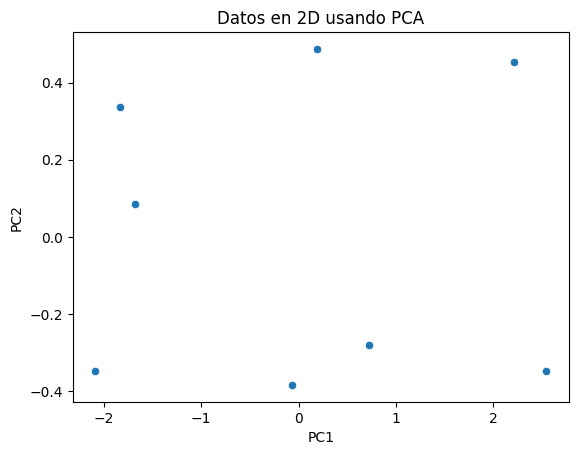

In [30]:
# Visualizar los datos en 2D con las dos primeras componentes principales

sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"])

plt.title("Datos en 2D usando PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [31]:
# Aplicar K-Means sobre datos originales

kmeans_original = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans_original.fit_predict(df[["Edad", "Ingresos", "Experiencia"]])

df

,Cliente,Edad,Ingresos,Experiencia,Cluster
0,1,25,50000,2,1
1,2,40,60000,10,2
2,3,35,70000,7,0
3,4,50,80000,15,0
4,5,30,45000,3,1
5,6,45,85000,20,0
6,7,38,72000,12,0
7,8,29,48000,4,1


In [32]:
# Aplicar K-Means sobre datos con PCA

kmeans_pca = KMeans(n_clusters=3, random_state=42)

df_pca["Cluster"] = kmeans_pca.fit_predict(df_pca)

df_pca

,PC1,PC2,Cluster
0,-2.088358,-0.349258,2
1,0.187607,0.487469,0
2,-0.065374,-0.384217,0
3,2.210591,0.452509,1
4,-1.830565,0.335839,2
5,2.544210,-0.346833,1
6,0.724952,-0.281611,0
7,-1.683062,0.086102,2


### Comparación y análisis:

Se compararon los resultados del clustering aplicado sobre los datos originales y sobre los datos transformados mediante PCA. Se observa que el agrupamiento de los clientes presenta algunas diferencias, ya que al reducir la dimensionalidad se reorganizan las distancias entre los datos.

El uso de PCA permite simplificar la estructura de los datos manteniendo la mayor parte de la información, lo que puede modificar levemente la asignación de algunos clientes a los clusters. Sin embargo, los grupos principales se mantienen, lo que indica que la segmentación sigue siendo consistente.

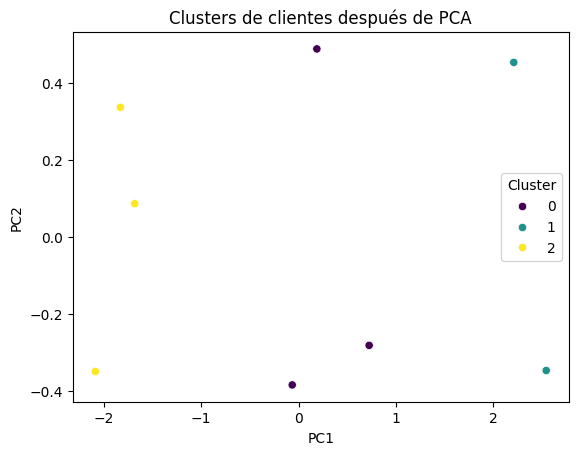

In [33]:
# Visualizar clusters después de PCA

sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca["Cluster"], palette="viridis")

plt.title("Clusters de clientes después de PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

### Interacción con una herramienta de IA (LLM) + reflexión
### Consulta realizada:

"Tengo un dataset de clientes con variables de edad, ingresos y experiencia. Apliqué K-Means y PCA. ¿Cómo puedo evaluar si los clusters obtenidos son adecuados?"

Reflexión (breve):
La IA sugiere evaluar la calidad de los clusters mediante métricas como la inercia o el método del codo. Esto complementa lo visto en clase, donde se trabajó con K-Means y PCA para segmentar datos. La herramienta resulta útil para profundizar el análisis y validar los resultados obtenidos.